<a href="https://colab.research.google.com/github/jinyoungkim0214/scaling-optimization/blob/ai-theories/scaling_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimization

gradient descent: x* = argminf(x)
initialization -> follow the slope of the derivative -> optimum

from derivative to gradient: direction of 'greatest increase' of the function
df(x)/dx -> gradientxf(x)
x' = x - a*gradientxf(x) 여기서 a(learning rate)을 작게: 화살표 짧게
a를 크게: 화살표 크게

Convergence of Gradient Descent

-> 문제점: not guaranteed to reach the global optimum
-> Convex function: all local minima are global minima
   (if line/plane segment between any two points lies above or on the graph)
-> Neural networks: non-convex
   - many different local minima
   - no (practical) way to say which is globally optimal

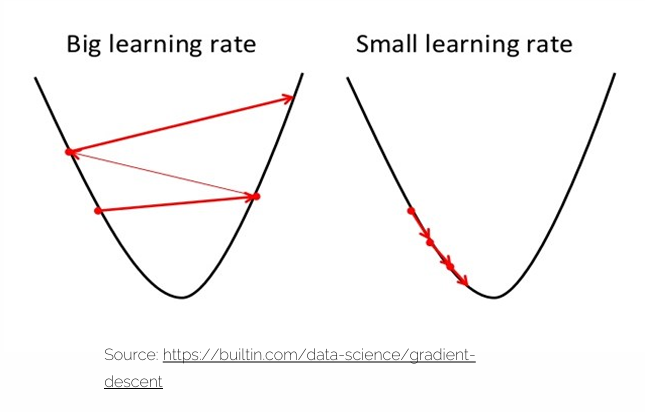

Gradient Descent for Neural Networks

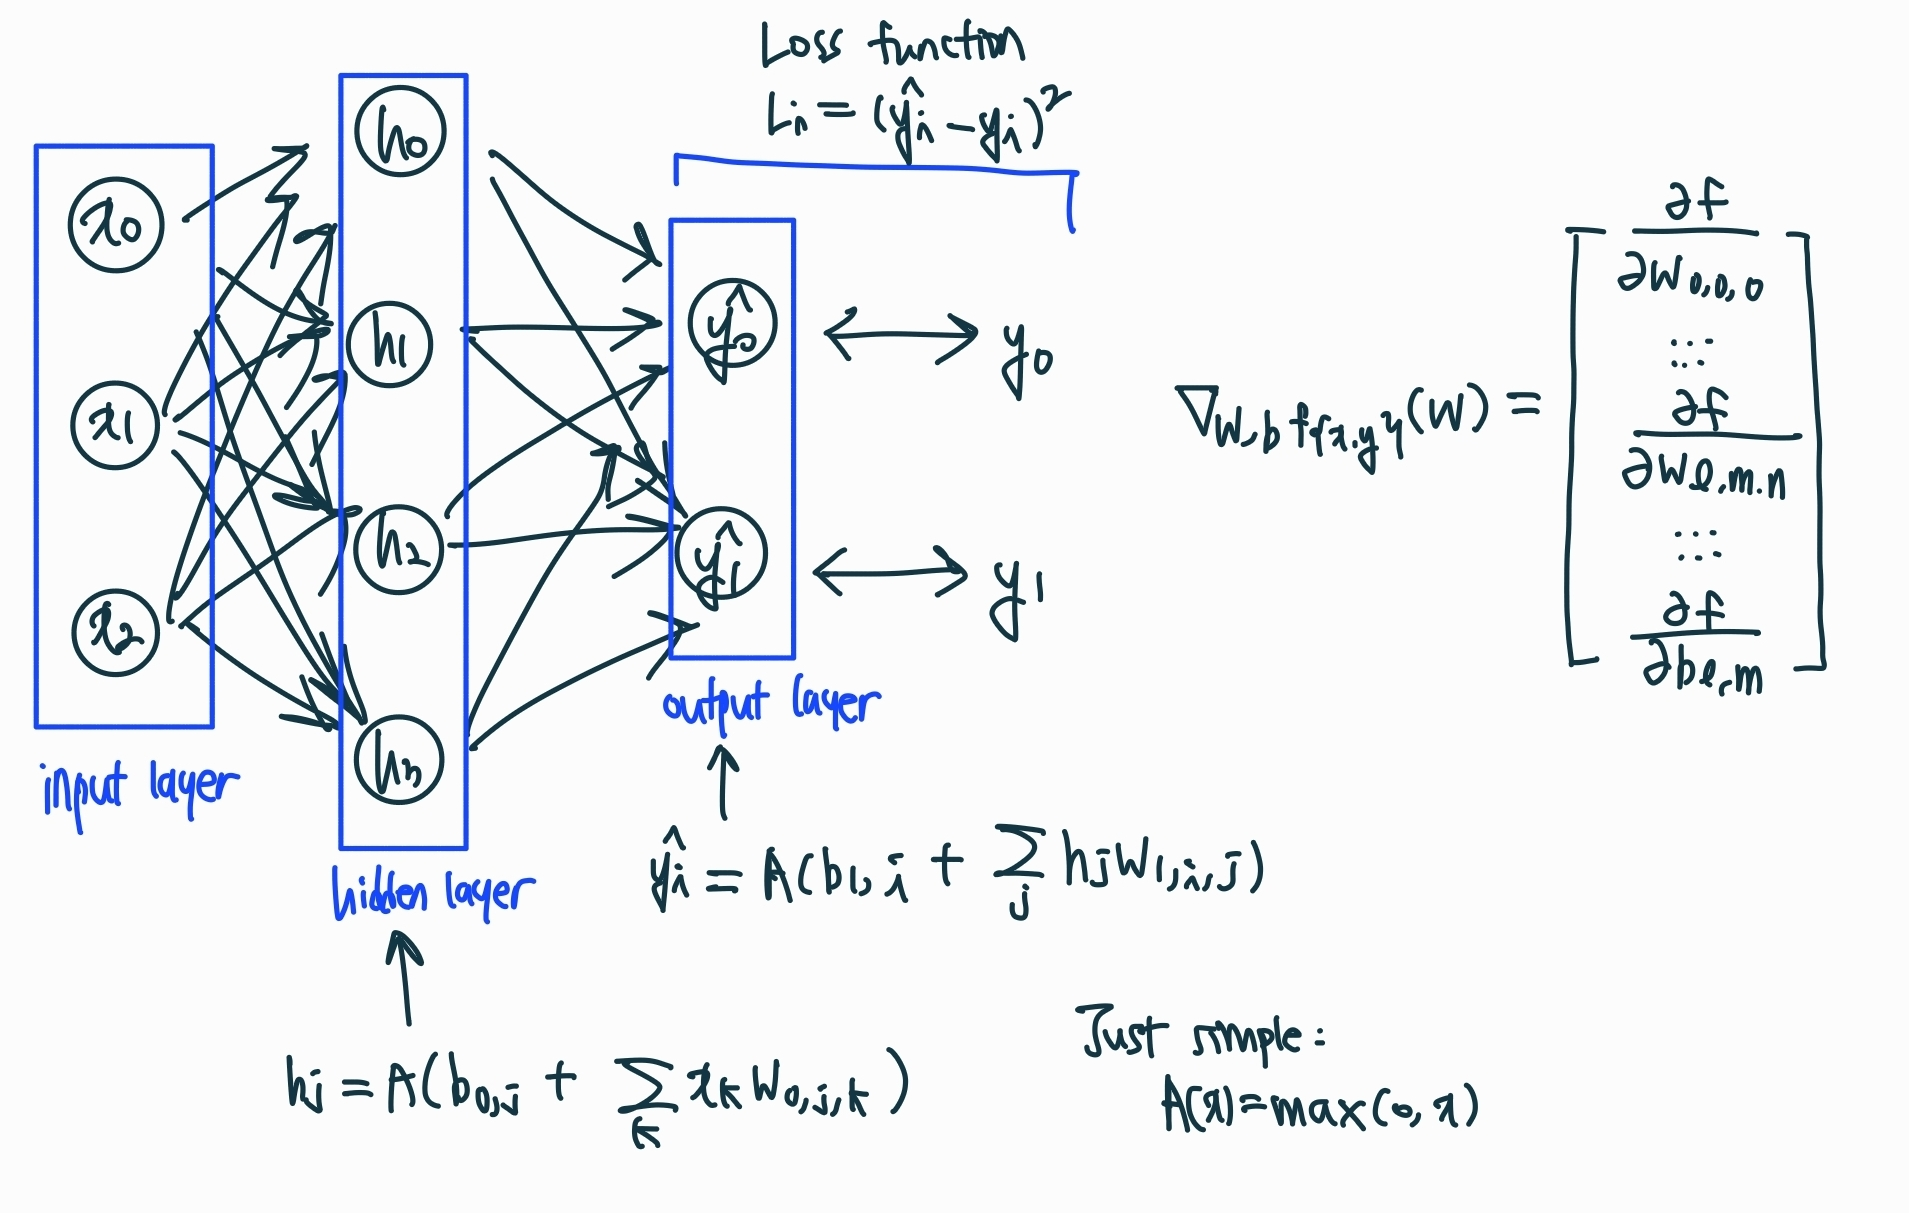

Gradient Descent: 'Single' Training Sample

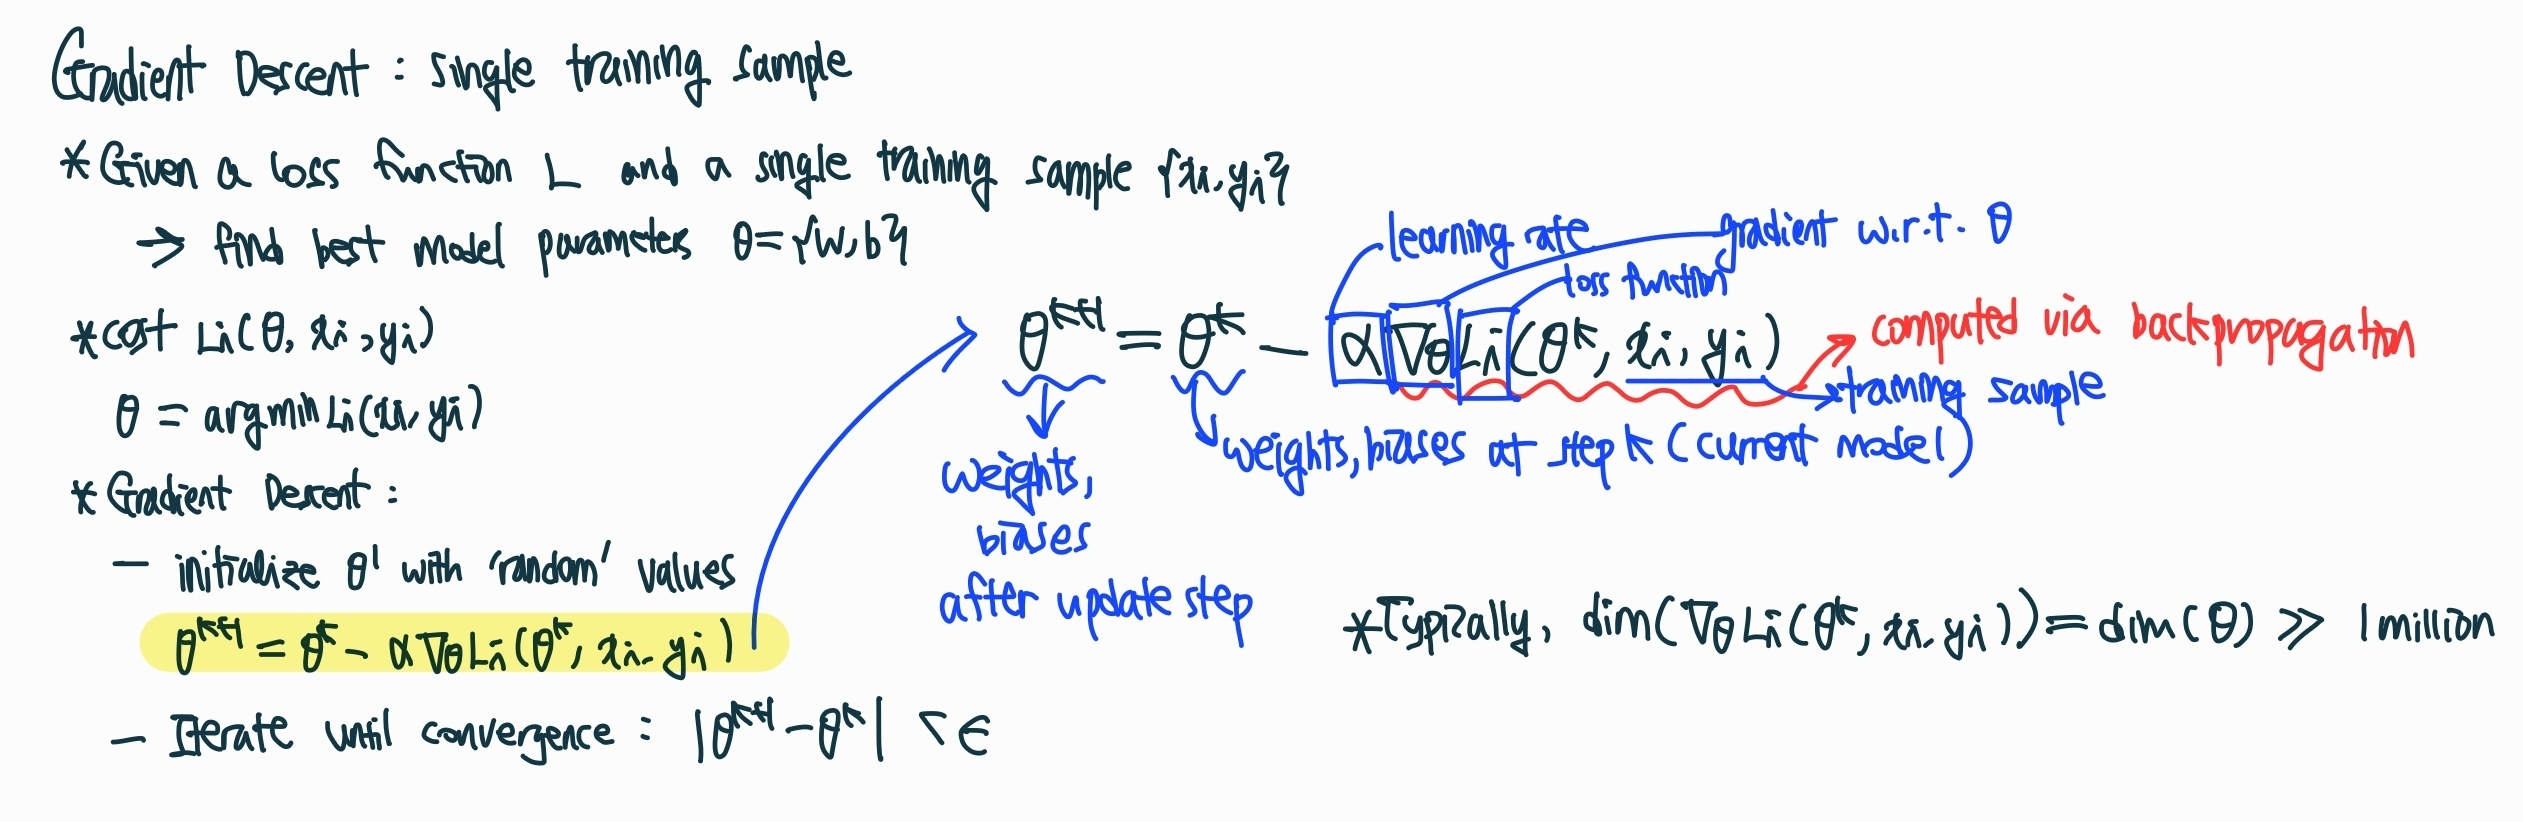

Gradient Descent: 'Multiple' Training Samples

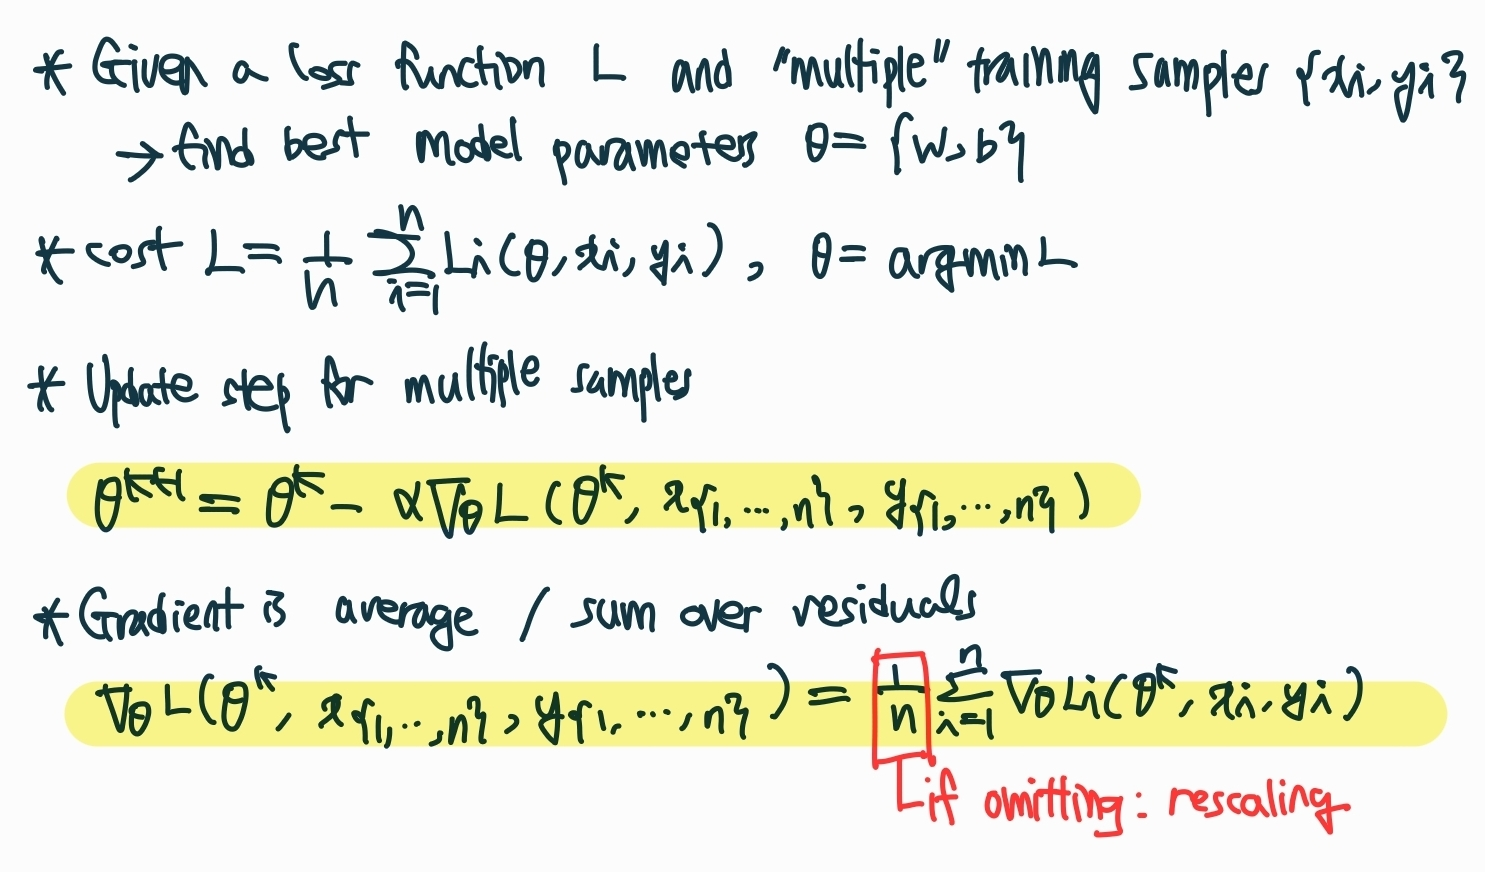

Optimal Learning Rate

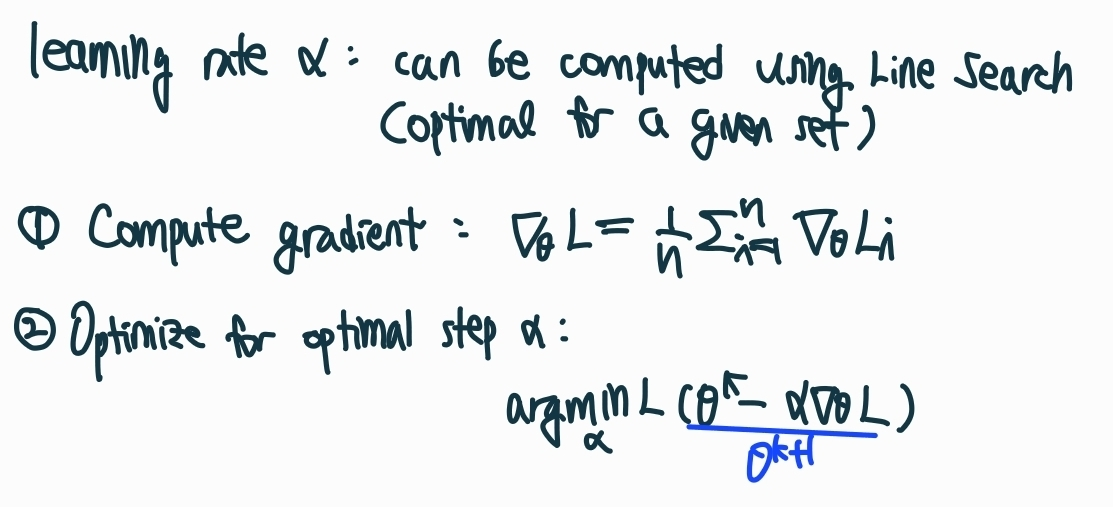

Gradient Descent on Train Set

Given large train set with n training samples {xi, yi}
만약 labeled images가 1 million개라면?
(network의 parameters는 500k개라고 하자)

Gradient has 500k dimensions
n = 1 million
-> extremely expensive to compute

"Stochastic Gradient Descent" (SGD)

만약 계산해야 하는 training samples가 n개라면,
the gradient for all of them which is O(n)

만약 해당 problem을 empirical risk minimization으로 생각해 본다면,
we can express the 'total loss' over the training data as the expectation of all the samples

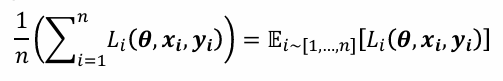

-> 이때 The expectation can be approximated with a small subset of the data
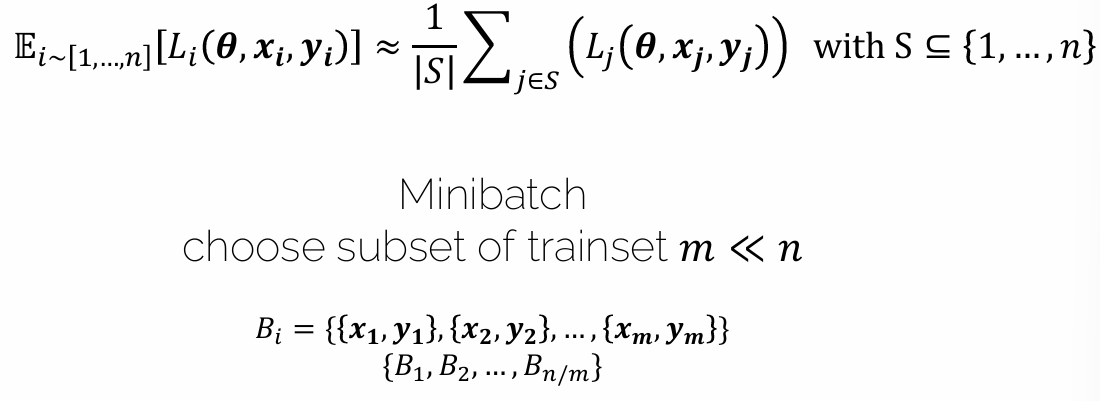

여기서 minibatch 의 size는 hyperparameter이고,
특징을 정리하자면

1. typically 2의 제곱수 (8, 16, 32, 64, 128, ...)
2. batch size가 작을수록 greater variance in the gradients -> noisy updates
3. 대부분 backward pass에서, GPU memory에 의해 limited
E.g.
Train set has n = 2^20 (about 1 million) images
With batch size m=64:
  B1, ... n/m = B 1, ... , 16384 minibatches
  (Epoch = complete pass through training set)

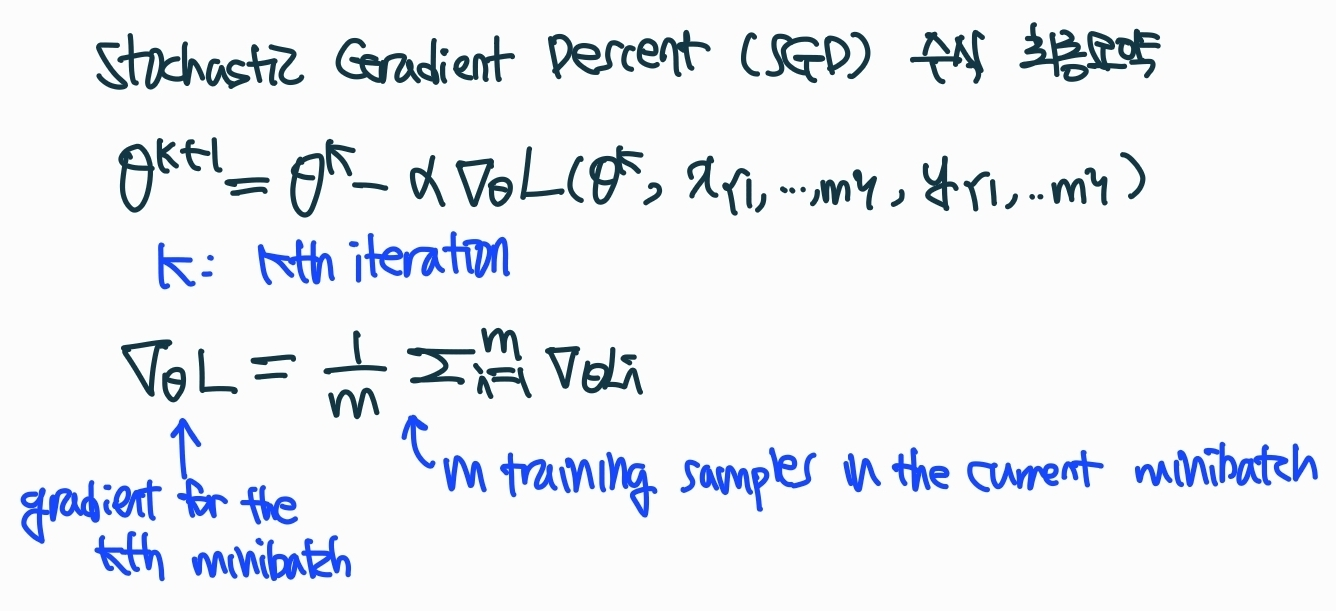

Convergence of SGD

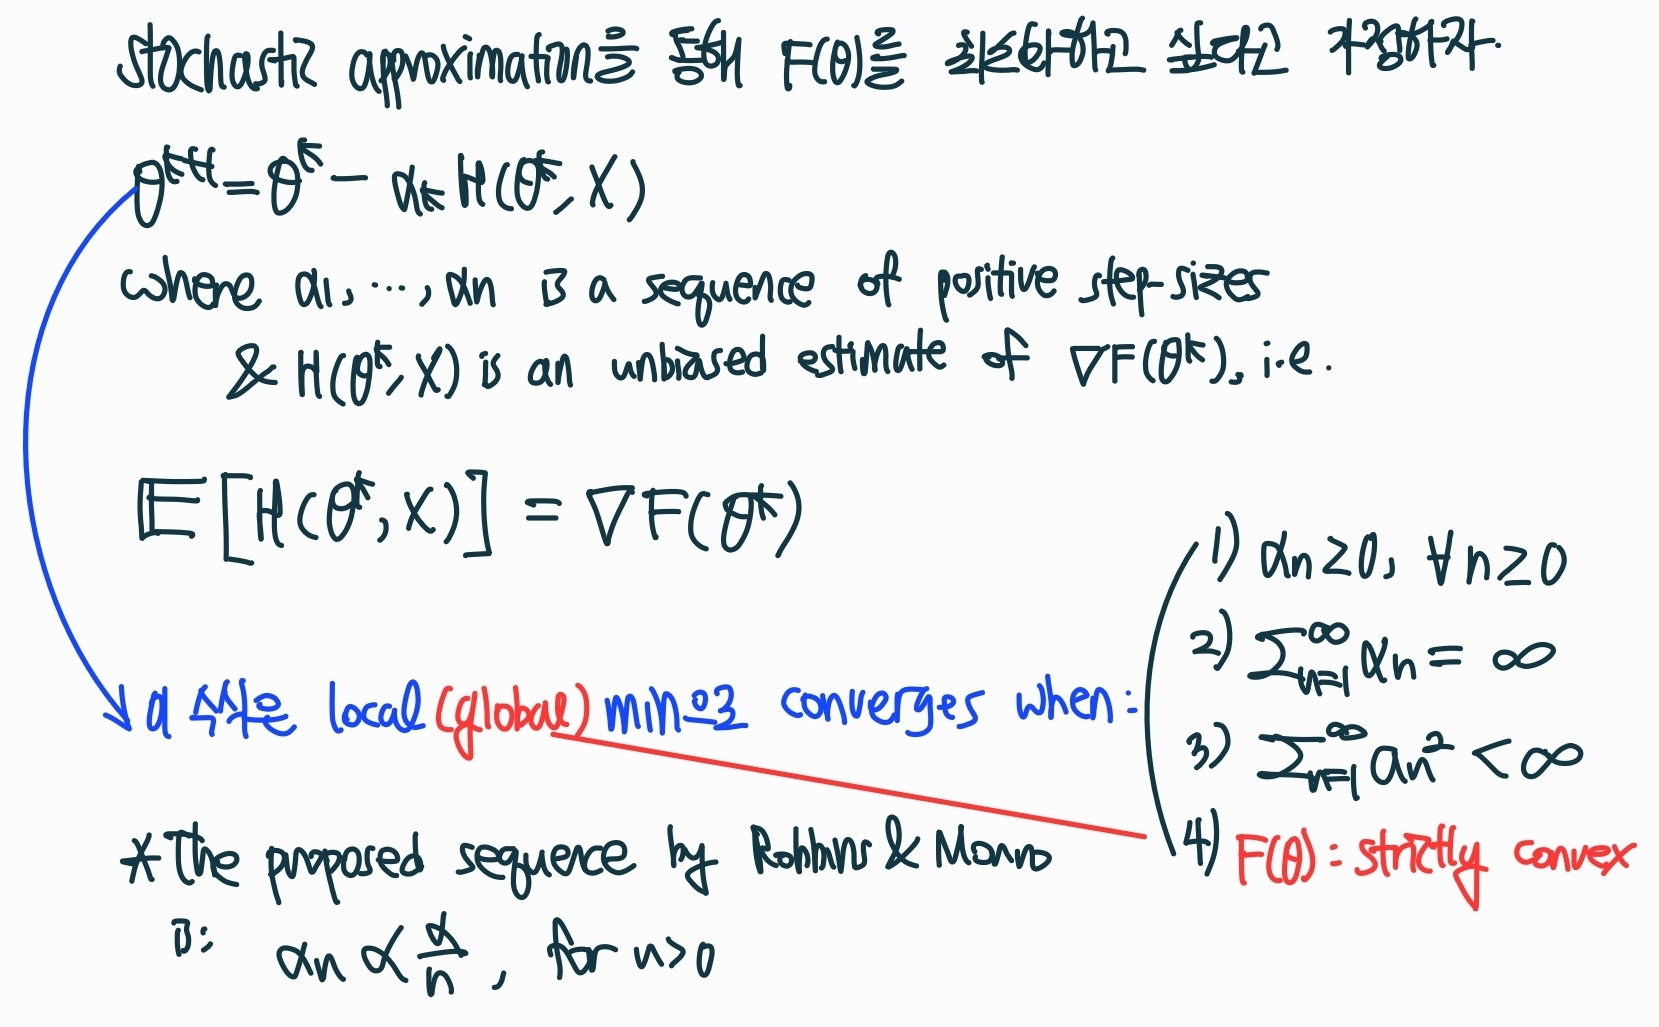

Problems of SGD

*Gradient is scaled equally across all dimensions
-> i.e. cannot independetly scale directions
-> need to have conservative min learning rate to avoid divergence
-> slower than 'necessary'

*Finding good learning rate is an art by itself

Gradient Descent with Momentum
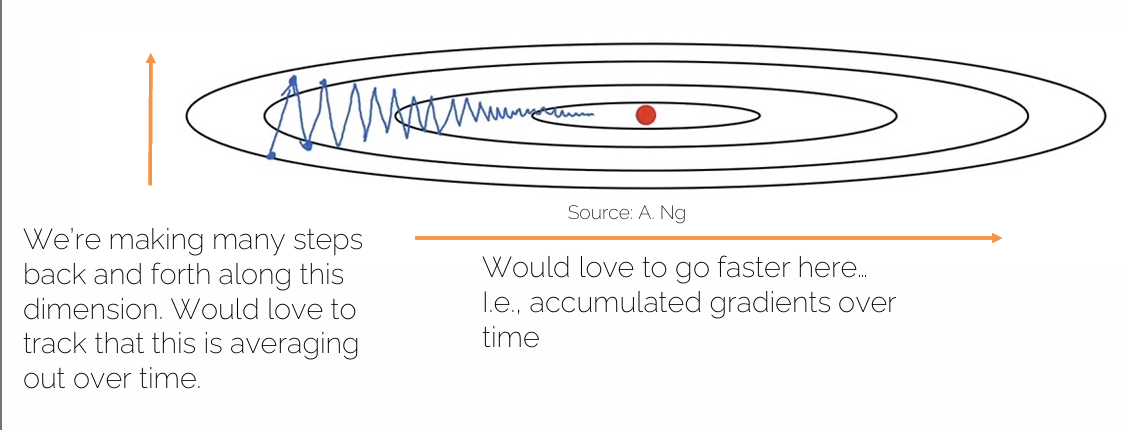

-> Gradient Descent of Momentum 수식 정리:
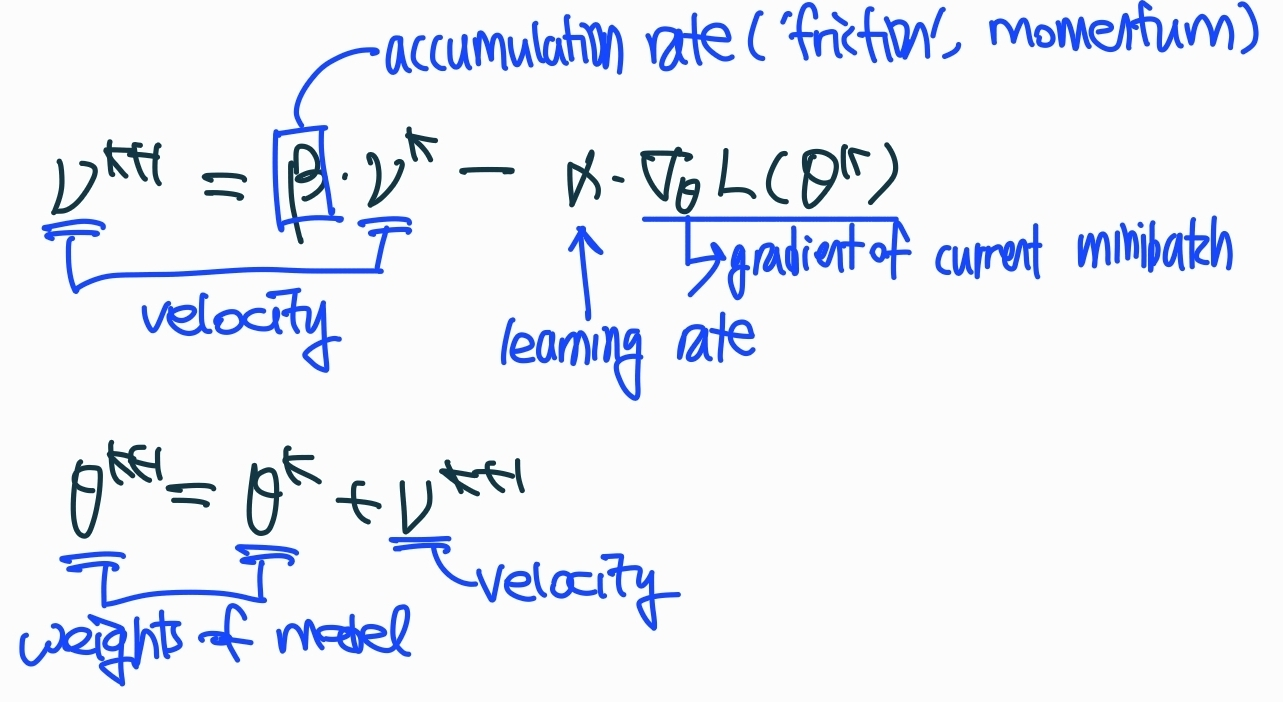

Nesterov Momentum

1. 기존 accumulated gradient의 방향으로 big jump
2. measure the gradient where you end up
3. make a correction